# 05 — Baseline Model Building

This notebook trains the five classification models required by the assignment: Decision Tree, Random Forest, Gradient Boosting, XGBoost, and an Artificial Neural Network. Models use the full Step 04 training set and are compared on validation data. Failure-class recall is primary, with PR-AUC, precision, F1, ROC-AUC, alert rate, and train-validation gaps providing essential context. The test set is not scored here.

In [1]:
from pathlib import Path
from time import perf_counter
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")
project_root = Path.cwd()
if not (project_root / "data" / "processed").exists():
    project_root = project_root.parent
data_dir = project_root / "data" / "processed"
results_dir = project_root / "reports" / "model_results"
figures_dir = project_root / "reports" / "figures"
models_dir = project_root / "models"
for directory in [results_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
THRESHOLD = 0.50

## 1. Load Approved Engineered Data

The selected feature list comes from Step 04's training/validation ablation. Administrative fields are retained only for traceability and are not predictors. Test data is loaded solely to verify schema and row integrity; its labels are not accessed for evaluation.

In [2]:
train_df = pd.read_csv(data_dir / "04_train_engineered.csv", parse_dates=["timestamp"])
validation_df = pd.read_csv(data_dir / "04_validation_engineered.csv", parse_dates=["timestamp"])
test_df = pd.read_csv(data_dir / "04_test_engineered.csv", parse_dates=["timestamp"])
selected_features = pd.read_csv(results_dir / "04_selected_features.csv")["feature"].tolist()
administrative = ["source_index", "timestamp", "turbine_id"]
target = "failure"
if len(selected_features) != len(set(selected_features)):
    raise RuntimeError("Selected feature list contains duplicates.")
for name, frame in {"train": train_df, "validation": validation_df, "test": test_df}.items():
    missing = set(selected_features + administrative + [target]) - set(frame.columns)
    if missing:
        raise RuntimeError(f"{name} is missing columns: {sorted(missing)}")
X_train = train_df[selected_features].copy()
y_train = train_df[target].astype("int8").copy()
X_validation = validation_df[selected_features].copy()
y_validation = validation_df[target].astype("int8").copy()
schema_report = pd.DataFrame({"train": [len(train_df), len(selected_features), int(y_train.sum())], "validation": [len(validation_df), len(selected_features), int(y_validation.sum())], "test_schema_only": [len(test_df), len(selected_features), np.nan]}, index=["rows", "predictors", "failure_count_used"]).T
display(schema_report)
print("Administrative fields excluded from predictors:", not set(administrative).intersection(X_train.columns))
print("Train/validation feature schemas identical:", X_train.columns.equals(X_validation.columns))
print("Test feature schema matches without scoring labels:", selected_features == [c for c in test_df.columns if c in selected_features])

,rows,predictors,failure_count_used
train,"92,310.0000",86.0000,"1,479.0000"
validation,"21,480.0000",86.0000,"1,219.0000"
test_schema_only,"17,970.0000",86.0000,NaN


Administrative fields excluded from predictors: True
Train/validation feature schemas identical: True
Test feature schema matches without scoring labels: True


## 2. Evaluation Policy

All baselines use the fixed 0.50 threshold. Recall measures missed failures directly and is the primary metric. PR-AUC is especially informative under class imbalance because it summarizes precision-recall performance across thresholds. ROC-AUC, precision, F1, predicted-positive rate, and train-validation gaps prevent a superficially high-recall model from being accepted without context. Threshold optimization is deferred until tuning.

In [3]:
def metric_row(y_true, probabilities, threshold=THRESHOLD):
    predictions = (probabilities >= threshold).astype("int8")
    return {"recall": recall_score(y_true, predictions), "precision": precision_score(y_true, predictions, zero_division=0), "f1": f1_score(y_true, predictions), "roc_auc": roc_auc_score(y_true, probabilities), "pr_auc": average_precision_score(y_true, probabilities), "predicted_positive_pct": predictions.mean() * 100}

negative_count = int(y_train.eq(0).sum())
positive_count = int(y_train.eq(1).sum())
scale_pos_weight = negative_count / positive_count
balanced_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
print(f"Training failures: {positive_count:,} of {len(y_train):,} ({y_train.mean() * 100:.3f}%)")
print(f"Training-derived scale_pos_weight: {scale_pos_weight:.4f}")
print(f"Baseline classification threshold: {THRESHOLD:.2f}")

Training failures: 1,479 of 92,310 (1.602%)
Training-derived scale_pos_weight: 61.4138
Baseline classification threshold: 0.50


## 3. Model-Specific Pipelines

`rated_power_kW` is one-hot encoded from training data. All other predictors receive median imputation. ANN numeric inputs additionally receive train-fitted standard scaling. The configurations are deliberately baseline settings rather than tuned solutions.

In [4]:
categorical_features = ["rated_power_kW"]
numeric_features = [c for c in selected_features if c not in categorical_features]
tree_preprocessor = ColumnTransformer([("numeric", SimpleImputer(strategy="median"), numeric_features), ("rated_power", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)], remainder="drop", verbose_feature_names_out=False)
ann_preprocessor = ColumnTransformer([("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features), ("rated_power", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features)], remainder="drop", verbose_feature_names_out=False)
models = {
    "Decision Tree": Pipeline([("preprocessor", tree_preprocessor), ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("preprocessor", tree_preprocessor), ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("preprocessor", tree_preprocessor), ("model", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE))]),
    "XGBoost": Pipeline([("preprocessor", tree_preprocessor), ("model", XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, subsample=1.0, colsample_bytree=1.0, reg_lambda=1.0, objective="binary:logistic", eval_metric="aucpr", scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1))]),
    "Artificial Neural Network": Pipeline([("preprocessor", ann_preprocessor), ("model", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", batch_size=256, learning_rate_init=0.001, max_iter=100, early_stopping=True, validation_fraction=0.15, n_iter_no_change=8, random_state=RANDOM_STATE))]),
}
fit_parameters = {"Decision Tree": {}, "Random Forest": {}, "Gradient Boosting": {"model__sample_weight": balanced_sample_weight}, "XGBoost": {}, "Artificial Neural Network": {"model__sample_weight": balanced_sample_weight}}
print("Baseline models configured:", list(models))

Baseline models configured: ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'Artificial Neural Network']


## 4. Train and Evaluate Baseline Models

In [5]:
results = []
validation_outputs = {}
for model_name, pipeline in models.items():
    started = perf_counter()
    pipeline.fit(X_train, y_train, **fit_parameters[model_name])
    fit_seconds = perf_counter() - started
    train_probabilities = pipeline.predict_proba(X_train)[:, 1]
    validation_probabilities = pipeline.predict_proba(X_validation)[:, 1]
    train_metrics = metric_row(y_train, train_probabilities)
    validation_metrics = metric_row(y_validation, validation_probabilities)
    row = {"model": model_name, "fit_seconds": fit_seconds}
    row.update({f"train_{key}": value for key, value in train_metrics.items()})
    row.update({f"validation_{key}": value for key, value in validation_metrics.items()})
    row["recall_gap"] = train_metrics["recall"] - validation_metrics["recall"]
    row["roc_auc_gap"] = train_metrics["roc_auc"] - validation_metrics["roc_auc"]
    row["pr_auc_gap"] = train_metrics["pr_auc"] - validation_metrics["pr_auc"]
    results.append(row)
    validation_outputs[model_name] = {"probabilities": validation_probabilities, "predictions": (validation_probabilities >= THRESHOLD).astype("int8")}
    joblib.dump(pipeline, models_dir / f"05_{model_name.lower().replace(' ', '_')}_baseline.joblib")
    print(f"Completed {model_name} in {fit_seconds:,.1f} seconds")
baseline_results = pd.DataFrame(results).sort_values(["validation_recall", "validation_pr_auc", "validation_precision"], ascending=False).reset_index(drop=True)
baseline_results.insert(0, "recall_rank", np.arange(1, len(baseline_results) + 1))
display(baseline_results[["recall_rank", "model", "validation_recall", "validation_precision", "validation_f1", "validation_pr_auc", "validation_roc_auc", "validation_predicted_positive_pct", "recall_gap", "pr_auc_gap", "fit_seconds"]])

Completed Decision Tree in 1.8 seconds


Completed Random Forest in 3.7 seconds


Completed Gradient Boosting in 130.4 seconds


Completed XGBoost in 1.6 seconds


Completed Artificial Neural Network in 3.7 seconds


,recall_rank,model,validation_recall,validation_precision,validation_f1,validation_pr_auc,validation_roc_auc,validation_predicted_positive_pct,recall_gap,pr_auc_gap,fit_seconds
0,1,XGBoost,0.6965,0.8117,0.7497,0.8707,0.9918,4.8696,0.3035,0.1293,1.6355
1,2,Artificial Neural Network,0.5373,0.8518,0.6590,0.6223,0.7161,3.5801,0.4627,0.3470,3.6586
2,3,Gradient Boosting,0.5308,0.6927,0.6010,0.5899,0.7430,4.3482,0.4692,0.3921,130.3569
3,4,Decision Tree,0.2116,0.8165,0.3362,0.2175,0.6044,1.4711,0.7884,0.7825,1.8485
4,5,Random Forest,0.1641,0.9091,0.2780,0.8187,0.9902,1.0242,0.8359,0.1813,3.6764


## 5. Validation Diagnostics

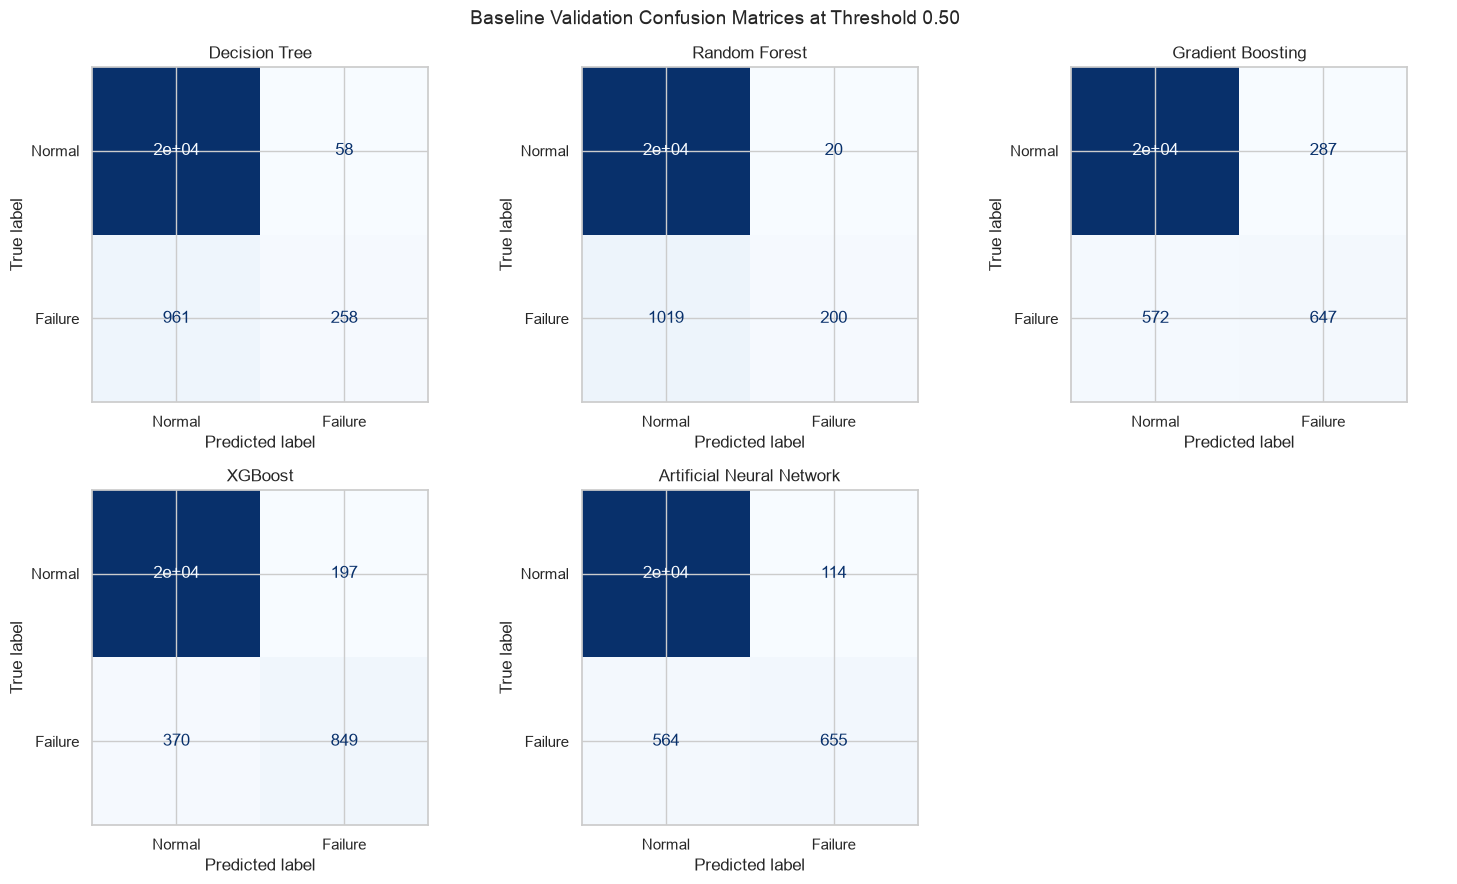

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, model_name in zip(axes.flat, models):
    matrix = confusion_matrix(y_validation, validation_outputs[model_name]["predictions"])
    ConfusionMatrixDisplay(matrix, display_labels=["Normal", "Failure"]).plot(ax=axis, colorbar=False, cmap="Blues")
    axis.set_title(model_name)
axes.flat[-1].axis("off")
fig.suptitle("Baseline Validation Confusion Matrices at Threshold 0.50", fontsize=14)
fig.tight_layout()
confusion_path = figures_dir / "05_baseline_confusion_matrices.png"
fig.savefig(confusion_path, dpi=160, bbox_inches="tight")
plt.show()

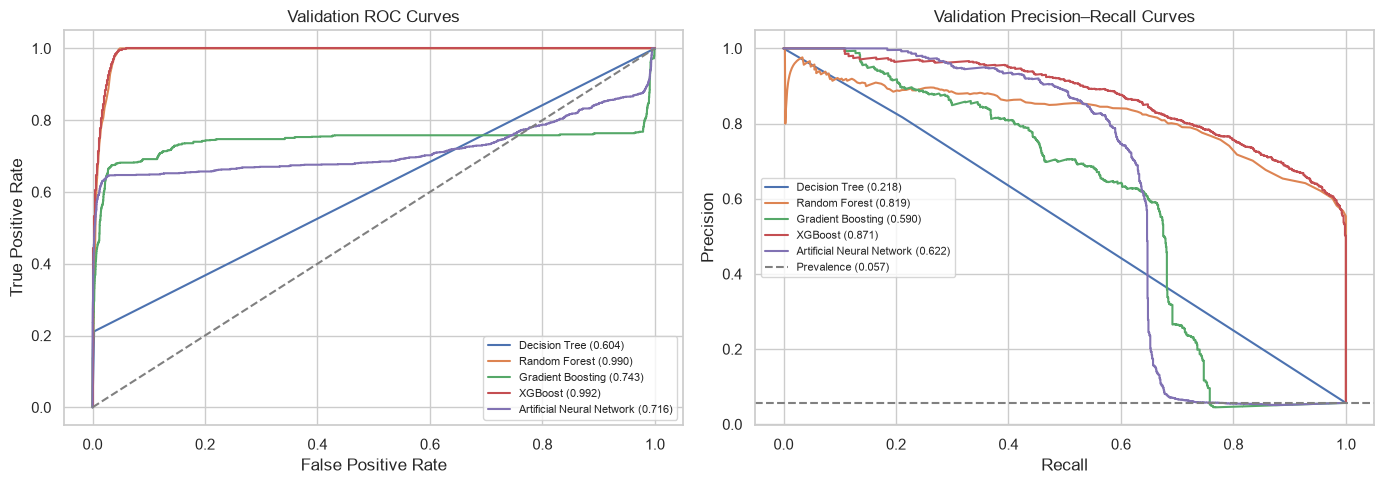

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, output in validation_outputs.items():
    probabilities = output["probabilities"]
    fpr, tpr, _ = roc_curve(y_validation, probabilities)
    precision, recall, _ = precision_recall_curve(y_validation, probabilities)
    row = baseline_results.loc[baseline_results["model"] == model_name].iloc[0]
    axes[0].plot(fpr, tpr, label=f"{model_name} ({row['validation_roc_auc']:.3f})")
    axes[1].plot(recall, precision, label=f"{model_name} ({row['validation_pr_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set(title="Validation ROC Curves", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].axhline(y_validation.mean(), linestyle="--", color="grey", label=f"Prevalence ({y_validation.mean():.3f})")
axes[1].set(title="Validation Precision–Recall Curves", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.legend(fontsize=8)
fig.tight_layout()
curves_path = figures_dir / "05_baseline_roc_pr_curves.png"
fig.savefig(curves_path, dpi=160, bbox_inches="tight")
plt.show()

In [8]:
report_rows = []
for model_name, output in validation_outputs.items():
    report = classification_report(y_validation, output["predictions"], target_names=["normal", "failure"], output_dict=True, zero_division=0)
    for class_name in ["normal", "failure"]:
        report_rows.append({"model": model_name, "class": class_name, **{key: report[class_name][key] for key in ["precision", "recall", "f1-score", "support"]}})
classification_reports = pd.DataFrame(report_rows)
display(classification_reports.loc[classification_reports["class"] == "failure"].sort_values("recall", ascending=False))

,model,class,precision,recall,f1-score,support
7,XGBoost,failure,0.8117,0.6965,0.7497,"1,219.0000"
9,Artificial Neural Network,failure,0.8518,0.5373,0.6590,"1,219.0000"
5,Gradient Boosting,failure,0.6927,0.5308,0.6010,"1,219.0000"
1,Decision Tree,failure,0.8165,0.2116,0.3362,"1,219.0000"
3,Random Forest,failure,0.9091,0.1641,0.2780,"1,219.0000"


## 6. Baseline Candidate Selection and Artifact Export

XGBoost is selected because it produced the strongest overall validation result. Random Forest is selected as the second tuning candidate because its 0.8187 PR-AUC demonstrates strong probability ranking despite conservative recall at the fixed 0.50 threshold. This gives threshold tuning a meaningful opportunity to recover recall. Train-validation gaps remain overfitting diagnostics. Final selection and threshold optimization occur after tuning, not here.

In [9]:
candidate_models = ["XGBoost", "Random Forest"]
baseline_path = results_dir / "05_baseline_metrics.csv"
reports_path = results_dir / "05_baseline_classification_reports.csv"
candidates_path = results_dir / "05_tuning_candidates.csv"
baseline_results.to_csv(baseline_path, index=False)
classification_reports.to_csv(reports_path, index=False)
pd.DataFrame({"rank": [1, 2], "model": candidate_models}).to_csv(candidates_path, index=False)
print("Recommended tuning candidates:", candidate_models)
print("Test probabilities or metrics calculated:", False)
print("Saved metrics:", baseline_path.relative_to(project_root))
print("Saved figures:", [str(confusion_path.relative_to(project_root)), str(curves_path.relative_to(project_root))])

Recommended tuning candidates: ['XGBoost', 'Random Forest']
Test probabilities or metrics calculated: False
Saved metrics: reports/model_results/05_baseline_metrics.csv
Saved figures: ['reports/figures/05_baseline_confusion_matrices.png', 'reports/figures/05_baseline_roc_pr_curves.png']


## Key Findings Recap

- All five rubric-required classifiers were trained on the complete 92,310-row training period using the same 86 selected predictors; preprocessing and imbalance treatment were fitted from training data only.
- XGBoost produced the strongest fixed-threshold validation result, with 0.6965 failure recall, 0.8117 precision, 0.7497 F1, 0.8707 PR-AUC, and 0.9918 ROC-AUC.
- The Artificial Neural Network ranked second by the recall-first rule, reaching 0.5373 validation recall, 0.8518 precision, 0.6590 F1, and 0.6223 PR-AUC.
- Gradient Boosting reached 0.5308 failure recall, while the untuned Decision Tree and Random Forest produced substantially lower recall of 0.2116 and 0.1641 at the fixed 0.50 threshold.
- Random Forest nevertheless achieved 0.8187 validation PR-AUC and 0.9091 precision, indicating useful ranking performance but an overly conservative baseline threshold that should be examined during tuning.
- Every model showed a positive train-validation recall gap; XGBoost had the smallest gap at 0.3035, while the other gaps ranged from 0.4627 to 0.8359 and warrant regularization checks.
- XGBoost and Random Forest were selected for tuning: XGBoost led the baseline comparison, while Random Forest's 0.8187 PR-AUC suggests its low fixed-threshold recall may improve through tuning and threshold selection.
- Test probabilities and metrics were not calculated; baseline pipelines, metrics, classification reports, confusion matrices, and ROC/precision-recall figures were saved for reproducible comparison.